# Linear Regression


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

## 3. Nonlinear

$$f(x) = \sin(3.2x) + 0.8x$$


### 3. 生成假資料

In [2]:
x = np.linspace(0, 5, 100)
y = np.sin(3.2*x) + 0.8*x + 0.3*np.random.randn(100)

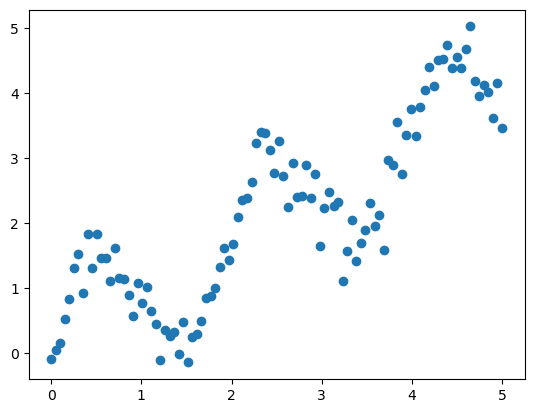

In [3]:
plt.scatter(x,y)
plt.show()

#### nonlinear

In [4]:
regr_lin = LinearRegression()

In [5]:
X = x.reshape(-1, 1)
print(X.shape)

(100, 1)


In [6]:
regr_lin.fit(X,y)

LinearRegression()

0.587000395355333


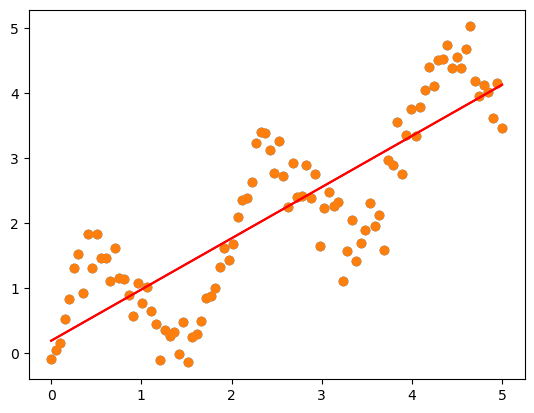

In [8]:
Y=regr_lin.predict(X)
plt.scatter(x,y)
plt.plot(x,Y , color='r')
mse = np.sum((Y-y)**2) / len(y)
print(mse)
plt.show()

果然超級不準, 該如何是好?

#### 多項式

多項式5次方

$$\widehat{y}=xw+b=w_{1}x_{1}+w_{2}x_{1}^{2}+w_{3}x_{1}^{3}+w_{4}x_{1}^{4}+w_{5}x_{1}^{5}+b$$

In [9]:
print(x.shape)

(100,)


In [10]:
X_poly = np.array([[k, k**2, k**3, k**4, k**5] for k in x])  # add k**6 to try it
print(X_poly.shape)

(100, 5)


In [11]:
regr_poly = LinearRegression()

In [12]:
regr_poly.fit(X_poly, y)

LinearRegression()

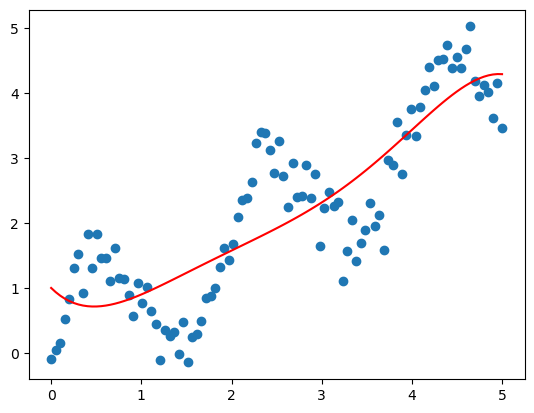

In [13]:
plt.scatter(x,y)
plt.plot(x, regr_poly.predict(X_poly), 'r')
plt.show()

In [14]:
print('Coefficients: ', regr_poly.coef_)
print('interception: ', regr_poly.intercept_)

Coefficients:  [-1.37399379  2.03137527 -0.94798572  0.20659738 -0.01640096]
interception:  1.0029851782848587


In [15]:
W=regr_poly.coef_
b=regr_poly.intercept_
np.dot(X_poly,W.T)+b

array([1.00298518, 0.93865232, 0.88396846, 0.83824844, 0.80083806,
       0.77111343, 0.74848034, 0.73237361, 0.72225645, 0.71761978,
       0.71798162, 0.72288644, 0.73190449, 0.74463118, 0.76068639,
       0.77971388, 0.80138062, 0.82537613, 0.85141183, 0.87922043,
       0.90855525, 0.93918958, 0.97091604, 1.00354592, 1.03690856,
       1.07085067, 1.10523571, 1.13994323, 1.17486821, 1.20992046,
       1.24502393, 1.28011605, 1.31514714, 1.35007972, 1.38488788,
       1.41955663, 1.45408124, 1.48846662, 1.52272664, 1.55688353,
       1.59096717, 1.62501451, 1.65906888, 1.69317934, 1.72740006,
       1.76178968, 1.79641061, 1.83132844, 1.86661127, 1.90232905,
       1.93855297, 1.97535477, 2.01280613, 2.050978  , 2.08993995,
       2.12975955, 2.17050171, 2.21222802, 2.25499611, 2.29885902,
       2.34386453, 2.39005454, 2.43746437, 2.4861222 , 2.53604834,
       2.58725462, 2.63974375, 2.69350865, 2.74853184, 2.80478474,
       2.86222707, 2.92080619, 2.98045644, 3.0410985 , 3.10263

In [16]:
regr_poly.predict(X_poly)

array([1.00298518, 0.93865232, 0.88396846, 0.83824844, 0.80083806,
       0.77111343, 0.74848034, 0.73237361, 0.72225645, 0.71761978,
       0.71798162, 0.72288644, 0.73190449, 0.74463118, 0.76068639,
       0.77971388, 0.80138062, 0.82537613, 0.85141183, 0.87922043,
       0.90855525, 0.93918958, 0.97091604, 1.00354592, 1.03690856,
       1.07085067, 1.10523571, 1.13994323, 1.17486821, 1.20992046,
       1.24502393, 1.28011605, 1.31514714, 1.35007972, 1.38488788,
       1.41955663, 1.45408124, 1.48846662, 1.52272664, 1.55688353,
       1.59096717, 1.62501451, 1.65906888, 1.69317934, 1.72740006,
       1.76178968, 1.79641061, 1.83132844, 1.86661127, 1.90232905,
       1.93855297, 1.97535477, 2.01280613, 2.050978  , 2.08993995,
       2.12975955, 2.17050171, 2.21222802, 2.25499611, 2.29885902,
       2.34386453, 2.39005454, 2.43746437, 2.4861222 , 2.53604834,
       2.58725462, 2.63974375, 2.69350865, 2.74853184, 2.80478474,
       2.86222707, 2.92080619, 2.98045644, 3.0410985 , 3.10263

#### RBF

$$\phi_i = e^{-\| x - c_i \|^2/2\sigma^2}$$

In [17]:
# normal distrubution
def RBF(x, center, sigma):
    k = np.exp(-(x - center)**2/(2*sigma**2))
    return k

In [18]:
sigma = 0.3

In [19]:
X_rbf = np.array([[RBF(k, .5, sigma), 
                  RBF(k, 1.5, sigma),
                  RBF(k, 2.5, sigma),
                  RBF(k, 3.5, sigma),
                  RBF(k, 4.5, sigma)] for k in x])



In [20]:
regr_rbf = LinearRegression()

In [21]:
regr_rbf.fit(X_rbf, y)

LinearRegression()

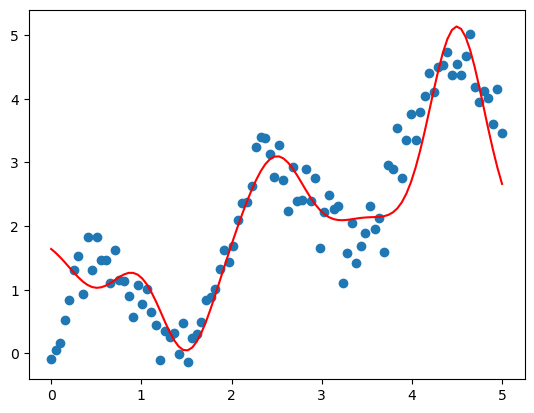

In [22]:
plt.scatter(x,y)
plt.plot(x, regr_rbf.predict(X_rbf), 'r')
plt.show()

In [23]:
print('Coefficients: ', regr_rbf.coef_)
print('interception: ', regr_rbf.intercept_)

Coefficients:  [-0.80380475 -1.79833723  1.26284894  0.27816682  3.29504105]
interception:  1.8412061266929982


#### Comparison

In [24]:
Y_lin = regr_lin.predict(X)
Y_poly = regr_poly.predict(X_poly)
Y_rbf = regr_rbf.predict(X_rbf)

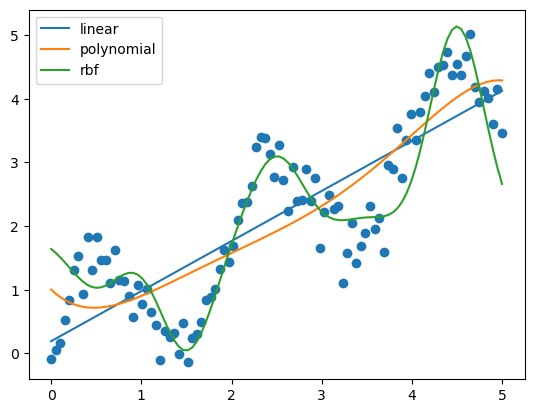

In [25]:
plt.scatter(x,y)

plt.plot(x, Y_lin, label='linear')
plt.plot(x, Y_poly, label='polynomial')
plt.plot(x, Y_rbf, label='rbf')
plt.legend()
plt.show()

## 請計算模型的MSE

In [26]:
print(np.sum((regr_lin.predict(X)-y)**2) / len(y))

0.587000395355333


In [27]:
print(np.sum((regr_poly.predict(X_poly)-y)**2) / len(y))

0.5319618569999788


In [28]:
print(np.sum((regr_rbf.predict(X_rbf)-y)**2) / len(y))

0.2788557394890623
